In [1]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_curve, precision_recall_curve, roc_auc_score, auc, average_precision_score, precision_score, recall_score
import cmcrameri.cm as cram
import shap
np.random.seed(42)

## Load healthy data

In [ ]:
healthy_data = np.load('data/ratData_healthy_all4_rats.npz')
print(healthy_data.keys())

healthy_labels = np.load('data/RatHealthyData_preGd_fit.npz')
inds = healthy_labels['roimasks'].reshape(-1)

KeysView(<numpy.lib.npyio.NpzFile object at 0x107d1f9d0>)


In [3]:
X_train = 1 - healthy_data['zspec'] # 1 - Z-spectrum
print(X_train.shape)

X_train = X_train[inds]
print(X_train.shape)

(147456, 52)
(17098, 52)


## Load tumor data

In [ ]:
tumor_data = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
for key in tumor_data.keys():
    print(key)

zspec
voxelInds_healthy
voxelInds_tumor
imageShape


In [5]:
imShape_tumor = tumor_data['imageShape']

tumorSpec = 1 - tumor_data['zspec'] # 1 - Z-spectrum
voxelInds_tumor = tumor_data['voxelInds_tumor']
voxelInds_healthy = tumor_data['voxelInds_healthy']

tumorIms = tumorSpec.reshape(imShape_tumor)

In [6]:
voxelInds_im_tumor = np.zeros(imShape_tumor[:-1])
voxelInds_im_tumor = voxelInds_im_tumor.reshape(-1,1)
voxelInds_im_tumor[voxelInds_tumor] = 1
voxelInds_im_tumor = voxelInds_im_tumor.reshape(imShape_tumor[:-1])
print(voxelInds_im_tumor.shape)

voxelInds_im_healthy = np.zeros(imShape_tumor[:-1])
voxelInds_im_healthy = voxelInds_im_healthy.reshape(-1,1)
voxelInds_im_healthy[voxelInds_healthy] = 1
voxelInds_im_healthy = voxelInds_im_healthy.reshape(imShape_tumor[:-1])
print(voxelInds_im_healthy.shape)

(3, 192, 192)
(3, 192, 192)


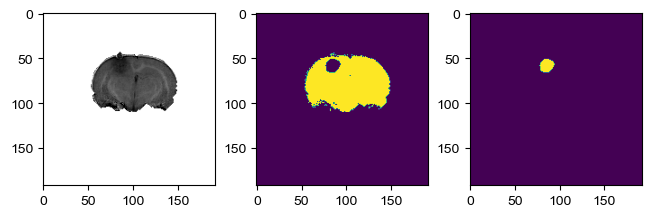

In [7]:
fig, ax = plt.subplots(1,3,layout='constrained')
ax[0].imshow(tumorIms[0,:,:,0], cmap='gray', vmin=0, vmax=1)
ax[1].imshow(voxelInds_im_healthy[0,:,:])
ax[2].imshow(voxelInds_im_tumor[0,:,:])

## Separate validation and test set from tumor data

In [8]:
from hypersearch import *

In [9]:
val_data = tumorIms[-1].reshape(-1,52)
val_tumor_inds = voxelInds_im_tumor[-1].reshape(-1)
val_healthy_inds = voxelInds_im_healthy[-1].reshape(-1)

In [10]:
test_data = tumorIms[:-1].reshape(-1,52)
test_tumor_inds = voxelInds_im_tumor[:-1].reshape(-1)
test_healthy_inds = voxelInds_im_healthy[:-1].reshape(-1)

In [11]:
val_all_inds = val_tumor_inds + val_healthy_inds

X_val = val_data[val_all_inds.astype(bool)]

y_val = val_all_inds
y_val[val_tumor_inds.astype(bool)] = 2
y_val_inds = np.nonzero(y_val)[0]
y_val = y_val[y_val_inds] - 1
print(np.unique(y_val, return_counts=True))

(array([0., 1.]), array([4083,  847]))


In [12]:
test_all_inds = test_tumor_inds + test_healthy_inds

X_test = test_data[test_all_inds.astype(bool)]

y_test = test_all_inds
y_test[test_tumor_inds.astype(bool)] = 2
y_test_inds = np.nonzero(y_test)[0]
y_test = y_test[y_test_inds]
y_test = y_test - 1

In [13]:
np.unique(y_test, return_counts=True)

(array([0., 1.]), array([8672,  648]))

## Perform hyperparameter search

In [14]:
iforest_param_dist = {
    "n_estimators": [50, 100, 15, 200, 250, 300, 400, 500],
    "bootstrap": [True, False]
}

results_if = randomized_search_iforest(
    iforest_param_dist,
    X_train,
    X_val,
    y_val,
    n_iter=40
)

/Users/anshumanswain/miniconda/lib/python3.10/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [15]:
results_if

[{'params': {'n_estimators': 100, 'bootstrap': True},
  'auc': 0.8856169546838171,
  'f1': 0.6310679611650486,
  'threshold': 0.05885932037398059},
 {'params': {'n_estimators': 400, 'bootstrap': False},
  'auc': 0.8881189057863962,
  'f1': 0.6306792622582096,
  'threshold': 0.0589792332159261},
 {'params': {'n_estimators': 400, 'bootstrap': True},
  'auc': 0.8895619554226194,
  'f1': 0.6305024455313473,
  'threshold': 0.05372438411724478},
 {'params': {'n_estimators': 250, 'bootstrap': True},
  'auc': 0.8880000613017779,
  'f1': 0.6288521661456007,
  'threshold': 0.05592188886844052},
 {'params': {'n_estimators': 300, 'bootstrap': False},
  'auc': 0.8891860482936564,
  'f1': 0.6286995515695067,
  'threshold': 0.054606532151547454},
 {'params': {'n_estimators': 500, 'bootstrap': True},
  'auc': 0.888354715219988,
  'f1': 0.6282676118741692,
  'threshold': 0.04374338112894263},
 {'params': {'n_estimators': 250, 'bootstrap': False},
  'auc': 0.8895341961269421,
  'f1': 0.627886323268206,


In [16]:
lof_param_grid = {
    "n_neighbors": [10, 20, 30, 40, 50],
    "leaf_size": [20, 30, 40, 50],
    "p": [1,2]
}

results_lof = grid_search_lof(
    lof_param_grid,
    X_train,
    X_val,
    y_val
)

In [17]:
results_lof

[{'params': {'n_neighbors': 50, 'leaf_size': 20, 'p': 1},
  'auc': 0.5925354675605159,
  'f1': 0.3653190452995616,
  'threshold': -0.45687262150734304},
 {'params': {'n_neighbors': 50, 'leaf_size': 30, 'p': 1},
  'auc': 0.5925354675605159,
  'f1': 0.3653190452995616,
  'threshold': -0.45687262150734304},
 {'params': {'n_neighbors': 50, 'leaf_size': 40, 'p': 1},
  'auc': 0.5925354675605159,
  'f1': 0.3653190452995616,
  'threshold': -0.45687262150734304},
 {'params': {'n_neighbors': 50, 'leaf_size': 50, 'p': 1},
  'auc': 0.5925354675605159,
  'f1': 0.3653190452995616,
  'threshold': -0.45687262150734304},
 {'params': {'n_neighbors': 50, 'leaf_size': 20, 'p': 2},
  'auc': 0.5896808866550367,
  'f1': 0.3628420326511842,
  'threshold': -0.4592973948190039},
 {'params': {'n_neighbors': 50, 'leaf_size': 30, 'p': 2},
  'auc': 0.5896808866550367,
  'f1': 0.3628420326511842,
  'threshold': -0.4592973948190039},
 {'params': {'n_neighbors': 50, 'leaf_size': 40, 'p': 2},
  'auc': 0.589680886655036

In [18]:
if_thresh = results_if[0]['threshold']
lof_thresh = results_lof[0]['threshold']

## Test IF and LOF on data

In [19]:
metrics = { 'IF': {'Accuracy': [],
                    'F1_score': [],
                    'FPR': [],
                    'TPR': [],
                    'ROC-AUC': []},
            'LOF': {'Accuracy': [],
                    'F1_score': [],
                    'FPR': [],
                    'TPR': [],
                    'ROC-AUC': [],
                    'Precision': [],
                    'Recall': [],
                    'PR-AUC': []}}

In [20]:
if_clf = IsolationForest(n_estimators=100, bootstrap=True, n_jobs=-1)
if_clf.fit(X_train)

if_scores = if_clf.decision_function(X_test)

if_predictions = (-if_scores >= if_thresh).astype(int)
print(np.unique(if_predictions, return_counts=True))

(array([0, 1]), array([7701, 1619]))


In [ ]:
explainer = shap.TreeExplainer(if_clf, data=X_train)
shap_values = explainer.shap_values(X_test[y_test == 1])

np.savez_compressed('data/ShapValues_IF.npz', shap_values=shap_values)

In [22]:
lof_clf = LocalOutlierFactor(n_neighbors=50, leaf_size=20, p = 1, novelty=True)
lof_clf.fit(X_train)

lof_scores = lof_clf.decision_function(X_test)

lof_predictions = (-lof_scores >= lof_thresh).astype(int)
print(np.unique(lof_predictions, return_counts=True))

(array([0, 1]), array([3248, 6072]))


In [23]:
predictions = [if_predictions,lof_predictions]
scores = [if_scores, lof_scores]
for key, prediction, score in zip(metrics.keys(), predictions, scores):
    metrics[key]['Accuracy'] = accuracy_score(y_test, prediction)
    metrics[key]['F1_score'] = f1_score(y_test, prediction)
    
    metrics[key]['FPR'], metrics[key]['TPR'], _ =  roc_curve(y_test, -score)
    metrics[key]['ROC-AUC'] = auc(metrics[key]['FPR'], metrics[key]['TPR'])

    metrics[key]['Precision'] = precision_score(y_test, prediction)
    metrics[key]['Recall'] = recall_score(y_test, prediction)
    metrics[key]['Precision_vals'], metrics[key]['Recall_vals'], _ = precision_recall_curve(y_test, -score)
    metrics[key]['PR-AUC'] = auc(metrics[key]['Recall_vals'], metrics[key]['Precision_vals'])
    metrics[key]['AP'] = average_precision_score(y_test, -score)

In [24]:
_, counts = np.unique(y_test, return_counts=True)
counts

array([8672,  648])

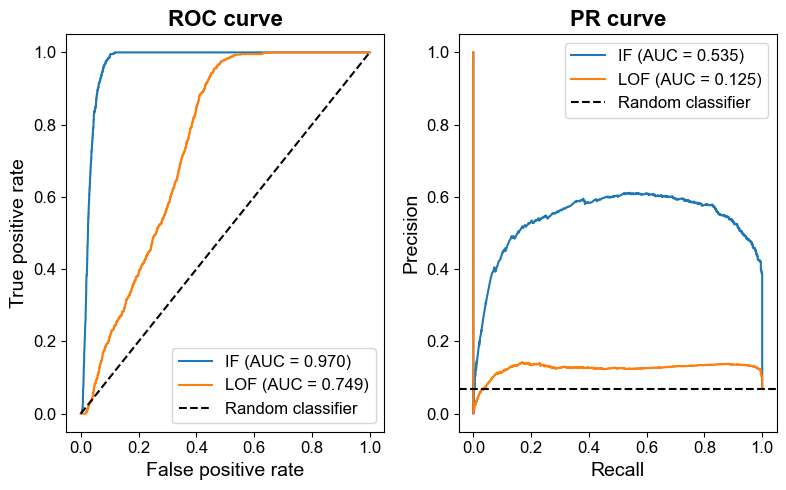

In [25]:
fig, ax = plt.subplots(1,2, figsize = (8,5))

ax[0].plot(metrics['IF']['FPR'], metrics['IF']['TPR'], label='IF (AUC = %0.3f)' % metrics['IF']['ROC-AUC'])
ax[0].plot(metrics['LOF']['FPR'], metrics['LOF']['TPR'], label='LOF (AUC = %0.3f)' % metrics['LOF']['ROC-AUC'])
ax[0].plot([0,1],[0,1],'k--', label='Random classifier')
ax[0].legend(fontsize=12)

ax[0].set_xlabel('False positive rate', fontsize=14)
ax[0].set_ylabel('True positive rate', fontsize=14)
ax[0].set_title('ROC curve', fontweight='bold', fontsize=16)

ax[1].plot(metrics['IF']['Recall_vals'], metrics['IF']['Precision_vals'], label='IF (AUC = %0.3f)' % metrics['IF']['PR-AUC'])
ax[1].plot(metrics['LOF']['Recall_vals'], metrics['LOF']['Precision_vals'], label='LOF (AUC = %0.3f)' % metrics['LOF']['PR-AUC'])
ax[1].axhline(y = counts[1] / np.sum(counts), color='k', linestyle='--', label='Random classifier')
ax[1].legend(fontsize=12)


ax[1].set_xlabel('Recall', fontsize=14)
ax[1].set_ylabel('Precision', fontsize=14)
ax[1].set_title('PR curve', fontweight='bold', fontsize=16)

for axes in ax:
    axes.tick_params(axis='both', labelsize=12)

plt.tight_layout()

In [ ]:
np.savez_compressed('data/FitMetrics_ZSpec_OptimThresh.npz', **metrics)

## Plot anomaly score maps

In [25]:
anoIms_if = np.zeros([2,192,192])
anoIms_lof = anoIms_if.copy()

In [26]:
anoIms_if = anoIms_if.reshape(-1)
anoIms_if[y_test_inds] = -if_scores
anoIms_if = anoIms_if.reshape([2,192,192])

In [27]:
anoIms_lof = anoIms_lof.reshape(-1)
anoIms_lof[y_test_inds] = -lof_scores
anoIms_lof = anoIms_lof.reshape((2,192,192))

Text(0, 0.5, 'Local outlier factor')

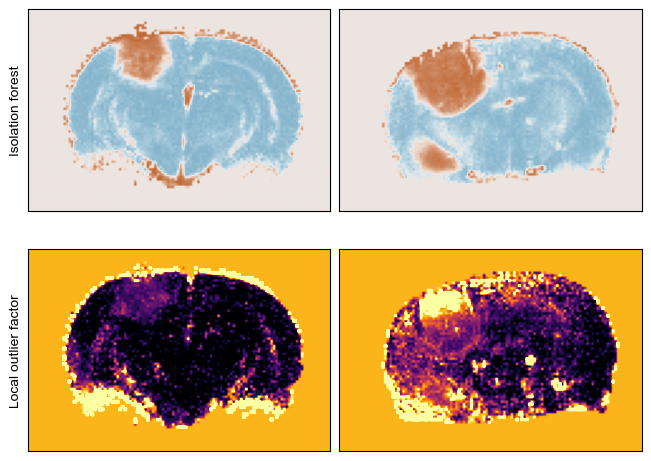

In [28]:
fig, ax = plt.subplots(2,2, layout='constrained')
ax[0,0].imshow(anoIms_if[0,40:120,40:160], cmap=cram.vik, vmin=-0.5, vmax=0.5)
ax[0,1].imshow(anoIms_if[1,25:105,30:150], cmap=cram.vik, vmin=-0.5, vmax=0.5)

ax[1,0].imshow(anoIms_lof[0,40:120,40:160], cmap='inferno', vmin=-0.5, vmax=0.1)
ax[1,1].imshow(anoIms_lof[1,25:105,30:150], cmap='inferno', vmin=-0.5, vmax=0.1)

for axes in ax.flat:
    axes.set_xticks([]) 
    axes.set_yticks([])

ax[0,0].set_ylabel('Isolation forest')
ax[1,0].set_ylabel('Local outlier factor')

Text(0.5, 1.0, 'Local outlier factor')

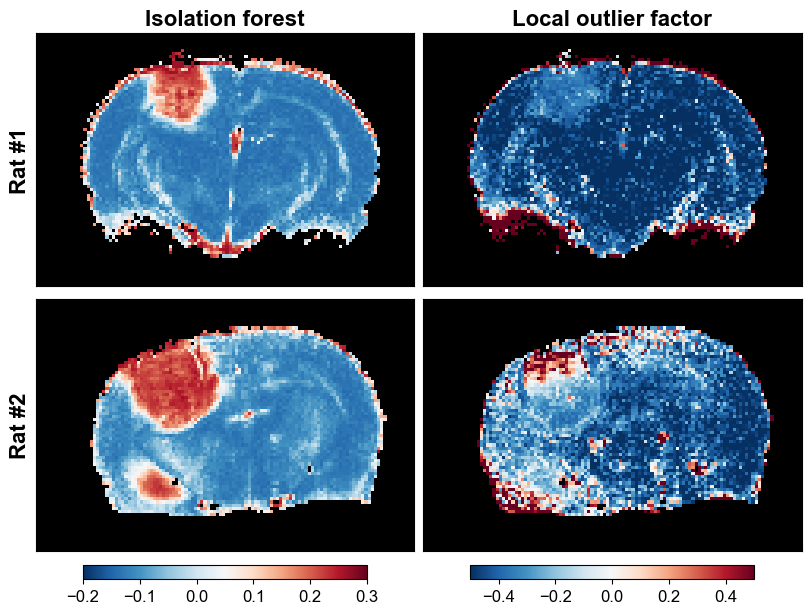

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(8,6), layout='constrained')
plt.style.use('default')

# Row 1 data
im00 = anoIms_if[0,40:120,40:160]
im10 = anoIms_if[1,25:105,30:150]

# Row 2 data
im01 = anoIms_lof[0,40:120,40:160]
im11 = anoIms_lof[1,25:105,30:150]

# Mask for zeros (0 → transparent)
mask00 = im00 != 0
mask01 = im01 != 0
mask10 = im10 != 0
mask11 = im11 != 0

# --- Plot row 1 (Isolation Forest) ---
ax[0,0].set_facecolor("black")
h00 = ax[0,0].imshow(im00, cmap='RdBu_r', vmin=-0.2, vmax=0.3, alpha=mask00.astype(float))

ax[1,0].set_facecolor("black")
h01 = ax[1,0].imshow(im10, cmap='RdBu_r', vmin=-0.2, vmax=0.3, alpha=mask10.astype(float))

# Colorbar for row 1 (on the right of row)
cbar1 = fig.colorbar(h01, ax=ax[1,0], location="bottom", shrink=0.75)
cbar1.ax.tick_params(labelsize=12)

# --- Plot row 2 (LOF) ---
ax[0,1].set_facecolor("black")
h10 = ax[0,1].imshow(im01, cmap='RdBu_r', vmin=-0.5, vmax=0.5, alpha=mask01.astype(float))

ax[1,1].set_facecolor("black")
h11 = ax[1,1].imshow(im11, cmap='RdBu_r', vmin=-0.5, vmax=0.5, alpha=mask11.astype(float))

# Colorbar for row 2
cbar2 = fig.colorbar(h11, ax=ax[1,1], location="bottom", shrink=0.75)
cbar2.ax.tick_params(labelsize=12)

# Remove ticks
for axes in ax.flat:
    axes.set_xticks([])
    axes.set_yticks([])

# Labels
ax[0,0].set_ylabel('Rat #1', fontweight='bold', fontsize=16)
ax[1,0].set_ylabel("Rat #2", fontweight='bold', fontsize=16)
for a in ax.flat:
    a.tick_params(colors="white")

ax[0,0].set_title('Isolation forest', fontweight='bold', fontsize=16)
ax[0,1].set_title('Local outlier factor', fontweight='bold', fontsize=16)